## Data Loading and Initial Setup

In this step, the dataset is loaded and basic preprocessing is performed.

- Required libraries such as pandas, seaborn, and matplotlib are imported.
- The dataset is loaded into a DataFrame.
- The `name` column is removed as it is an identifier and does not contribute to model prediction.

This ensures that only relevant numerical features are used for further analysis.

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
df = pd.read_csv("../data/parkinsons.csv")

# Drop unnecessary column
df.drop("name", axis=1, inplace=True)

df.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## Correlation Matrix Analysis

A correlation heatmap is generated to understand relationships between features.

- It shows how strongly features are related to each other.
- Helps identify redundant features.
- Provides an overview of feature dependencies.

This step is important for detecting multicollinearity and guiding feature selection.

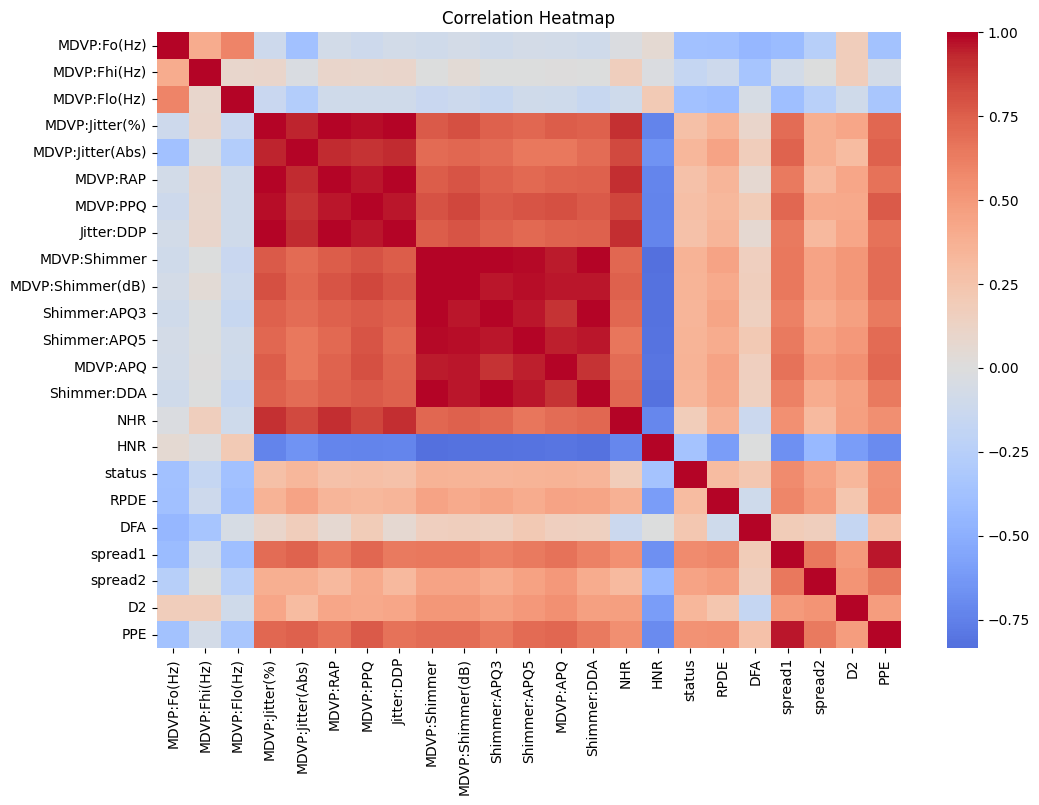

In [4]:
plt.figure(figsize=(12,8))
corr = df.corr()

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## Correlation with Target Variable

Correlation analysis was performed to identify features most relevant to the target variable (`status`).

### Top Correlated Features:
- spread1 (0.56)
- PPE (0.53)
- spread2 (0.45)
- MDVP:Fo(Hz) (0.38)
- MDVP:Flo(Hz) (0.38)
- MDVP:Shimmer (0.36)
- HNR (0.36)

### Key Insights:
- `spread1` and `PPE` show the strongest relationship with the target, indicating high predictive importance.
- Several shimmer and jitter-based features also show moderate correlation.
- Some features (e.g., Jitter variants, Shimmer variants) are likely redundant due to high inter-correlation.

### Conclusion:
Features with higher correlation were prioritized, while redundant features were removed to improve model efficiency and reduce overfitting.

In [5]:
corr_target = corr["status"].abs().sort_values(ascending=False)

print(corr_target)

status              1.000000
spread1             0.564838
PPE                 0.531039
spread2             0.454842
MDVP:Fo(Hz)         0.383535
MDVP:Flo(Hz)        0.380200
MDVP:Shimmer        0.367430
MDVP:APQ            0.364316
HNR                 0.361515
Shimmer:APQ5        0.351148
MDVP:Shimmer(dB)    0.350697
Shimmer:APQ3        0.347617
Shimmer:DDA         0.347608
D2                  0.340232
MDVP:Jitter(Abs)    0.338653
RPDE                0.308567
MDVP:PPQ            0.288698
MDVP:Jitter(%)      0.278220
MDVP:RAP            0.266668
Jitter:DDP          0.266646
DFA                 0.231739
NHR                 0.189429
MDVP:Fhi(Hz)        0.166136
Name: status, dtype: float64


## Top Feature Identification

The top correlated features are selected based on their relationship with the target variable.

- The target variable itself is excluded.
- Only top features are considered to reduce noise.

This step reduces dimensionality and focuses on the most relevant features.

In [6]:
top_features = corr_target[1:10]  # excluding 'status'
print(top_features)

spread1         0.564838
PPE             0.531039
spread2         0.454842
MDVP:Fo(Hz)     0.383535
MDVP:Flo(Hz)    0.380200
MDVP:Shimmer    0.367430
MDVP:APQ        0.364316
HNR             0.361515
Shimmer:APQ5    0.351148
Name: status, dtype: float64


## Key Observations from Top Correlation Analysis

- **Strong Positive Correlation**
  - `spread1` and `PPE` (~0.96) → highly redundant (carry similar information)
  - `MDVP:Shimmer` and `Shimmer:APQ5` (~0.98)
  - `MDVP:Shimmer` and `MDVP:APQ` (~0.95)

- **Negative Correlation**
  - `HNR` vs Shimmer-related features (~ -0.8)
  - Interpretation: Higher voice clarity → lower noise

- **Weak Correlation**
  - `MDVP:Fo(Hz)` has low correlation with noise-based features
  - Indicates it captures a different aspect (pitch, not noise)

---

## Top Feature Selection

- Selected based on **highest correlation with target (`status`)**
- Removed redundant features to avoid **multicollinearity**
- Focused on **diverse and informative signals**

### Final Selected Features:
- `spread1`
- `PPE`
- `spread2`
- `MDVP:Fo(Hz)`

---

## Why This Matters

- Reduces **dimensionality**
- Avoids **overfitting**
- Improves **model generalization**
- Keeps only **high-impact features for prediction**

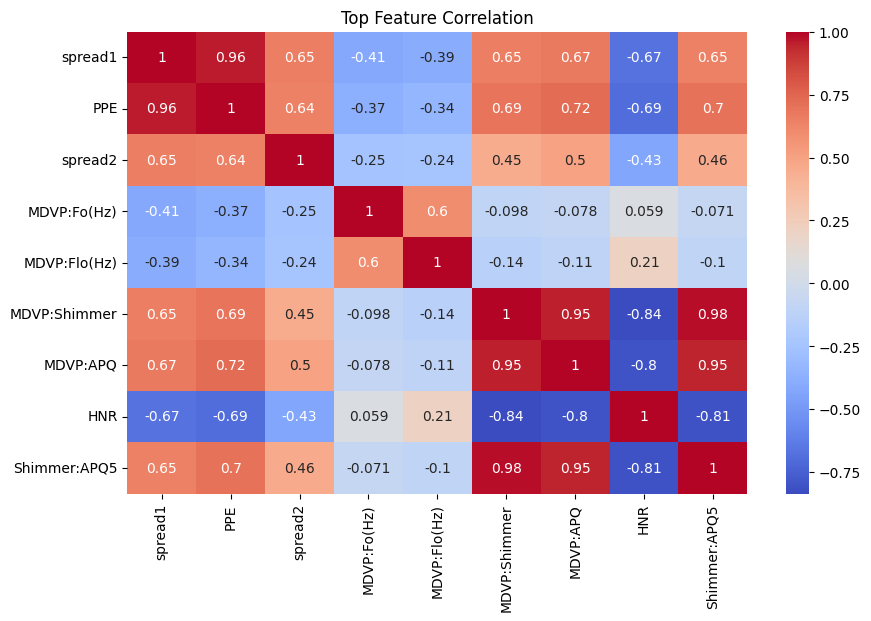

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df[top_features.index].corr(), annot=True, cmap="coolwarm")
plt.title("Top Feature Correlation")
plt.show()

## Final Feature Selection

A subset of features is selected based on:

- High correlation with the target variable
- Low multicollinearity
- Domain relevance

Final selected features:
- spread1
- PPE
- spread2
- MDVP:Fo(Hz)

These features capture key variations in voice signals and provide strong predictive power.

In [8]:
features = ["spread1", "PPE", "spread2", "MDVP:Fo(Hz)"]

X = df[features]
y = df["status"]

print("Selected Features:", features)

Selected Features: ['spread1', 'PPE', 'spread2', 'MDVP:Fo(Hz)']


## Saving Processed Dataset

The selected features along with the target variable are saved into a new dataset.

- This ensures a clean and ready-to-use dataset for model training.
- Avoids repeating preprocessing steps.

This improves workflow efficiency and reproducibility.

In [11]:
selected_df = df[features + ["status"]]
selected_df.to_csv("../data/selected_features.csv", index=False)